# Import Libraries

In [2]:
!pip install gensim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import FastText
from sklearn.decomposition import PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.4 MB/s eta 0:00:00


# Load Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Path to dataset files:", path)

100%|██████████| 1.83M/1.83M [00:00<00:00, 49.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yufengdev/bbc-fulltext-and-category/versions/2


In [4]:
import os

# The file identified by os.listdir(path) is 'bbc-text.csv'.
csv_file_name = 'bbc-text.csv'

# Construct the full path to the CSV file.
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# Text Preprocessing

In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess_text(text):
  # Lowercase
  text = text.lower()
  # Remove special character
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # Tokenize and remove stopwords
  words = nltk.word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  words = [w for w in words if w not in stop_words]
  return words

df['tokenized_text'] = df['text'].apply(preprocess_text)
tokenized_data = df['tokenized_text'].tolist()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [6]:

def load_glove(file_path):
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove_path = "glove.6B.100d.txt"
glove_embeddings = load_glove(glove_path)

print("GloVe loaded")

GloVe loaded


# GloVe similar words manually (cosine similarity)

In [7]:
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

# Example comparison

In [8]:
word1, word2 = "market", "economy"

if word1 in glove_embeddings and word2 in glove_embeddings:
    sim = cosine_similarity(glove_embeddings[word1], glove_embeddings[word2])
    print("GloVe Similarity:", sim)

GloVe Similarity: 0.712294


# Train FastText Model

In [9]:

fasttext_model = FastText(
    sentences=tokenized_data,
    vector_size=100,
    window=5,
    min_count=2
)

print("FastText model trained")

FastText model trained


# FastText Similar Words

In [10]:
print("\nFastText Similar Words:")
print(fasttext_model.wv.most_similar("market"))


FastText Similar Words:
[('upmarket', 0.996864914894104), ('markets', 0.9952935576438904), ('stockmarket', 0.9932370781898499), ('nonmarket', 0.9925420880317688), ('marketset', 0.9913221001625061), ('firm', 0.9835843443870544), ('shares', 0.9775221347808838), ('prices', 0.9769043922424316), ('profits', 0.9749100208282471), ('share', 0.9738170504570007)]


# Misspelled Word Test

In [11]:
print("\nMisspelled Word Test (FastText):")
print(fasttext_model.wv["goverment"])  # works


Misspelled Word Test (FastText):
[ 0.17167956  0.48754793 -0.6981584  -0.30723232  0.67761666  0.28404173
  0.5868612  -0.58102864  0.8003216  -0.20892432 -0.3853527   0.02102429
 -0.7512344   0.5057549  -0.20524372 -0.02696946  0.22557108 -0.4479264
 -0.5109192  -0.9846522  -0.34031388  0.41906986  0.26886165 -0.15333623
  0.15986338 -0.38448986 -1.0492796  -0.08826859  0.7675246   0.38633347
 -0.16744976  0.64331585  0.26156557 -0.535224    0.04851131 -0.01331248
  0.80229604  0.909956   -1.0941786   0.5771688   0.64986366 -0.45129243
  0.42857406 -0.59912455 -0.31268036  0.08365168  0.51865953 -0.31692156
  0.84182745  0.39382136  0.4360368   0.84195834  0.5280524   0.20118381
  0.3439545  -0.06142676 -0.6938701   0.05323009 -0.48684883 -0.18862674
 -0.03275849 -0.85671073  0.11954319 -0.20010382 -0.3453985   0.7775944
  0.01252573  0.29391015 -0.5359229   0.80841863  0.12112221 -0.296465
  0.10058954 -0.5659618   0.03192884 -0.41501266  0.37497103 -0.8787053
  0.4574016   0.223041

# Visualization (PCA)

In [14]:
def plot_embeddings(model, title):
    words = list(model.wv.index_to_key)[:30]
    vectors = model.wv[words]

    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))
    plt.scatter(result[:,0], result[:,1])

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i,0], result[i,1]))

    plt.title(title)
    plt.show()


# Plot FastText embeddings

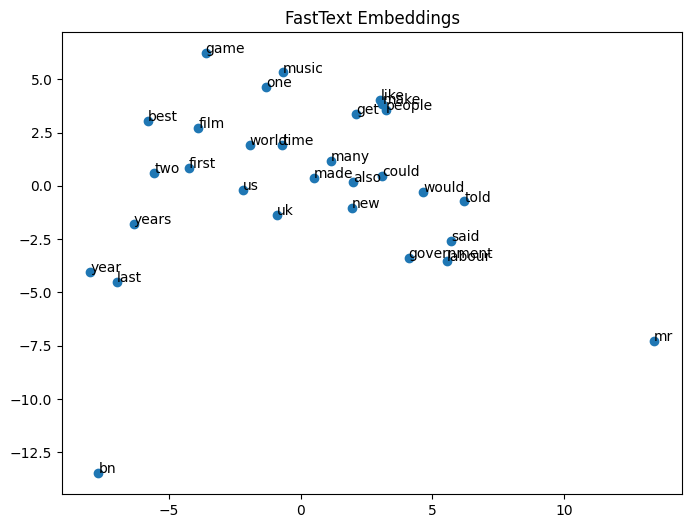

In [15]:
plot_embeddings(fasttext_model, "FastText Embeddings")